# Analítica de Recursos Humanos: Determinantes Salariales y Modelación de Compensaciones

**Proyecto 01 *
TalentCo

Integrantes: Miguel Nova, Martina Morales e Ivania Becerra
Profesor: Francisco Alfaro

## Estructura del notebook
1. Análisis Exploratorio de Datos (EDA)
2. Pruebas de Hipótesis
3. Regresión Lineal con Variables Categóricas
4. Análisis y Refinamiento del Modelo
5. Conclusiones para el Informe de Negocio


## Configuración del entorno

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 90
RANDOM_STATE = 42

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## Parte 1: Análisis Exploratorio de Datos (EDA)

### 1.1 Carga del dataset
Cargamos el archivo `employee_compensation.csv` desde la carpeta local del proyecto.


In [2]:
df_raw = pd.read_csv("employee_compensation.csv")
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
df_raw.head(10)


Filas: 10,100 | Columnas: 9


,Salary,Years_Experience,Age,Performance_Score,Education_Level,Department,Region,Job_Level,Gender
0,69181.0,3.0,22.0,3.5,Bachelor,Sales,East,Junior,Male
1,88466.0,5.0,23.0,2.8,bachelor,FINANCE,West,Junior,Female
2,76112.0,11.0,29.0,1.6,Master,HR,West,Mid,Female
3,NaN,15.0,37.0,NaN,Bachelor,Marketing,South,Senior,Male
4,NaN,6.0,28.0,4.5,Bachelor,Engineering,North,Mid,Female
5,81246.0,4.0,21.0,2.8,Bachelor,Engineering,West,Junior,Male
6,71494.0,4.0,23.0,2.4,Bachelor,Engineering,South,Junior,Male
7,78189.0,3.0,21.0,3.5,Master,Finance,East,Junior,NaN
8,67204.0,0.0,21.0,3.5,Master,Marketing,East,Junior,Female
9,59776.0,4.0,24.0,NaN,Bachelor,HR,East,Junior,Female


### 1.2 Tipos de datos e información general

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Salary             9897 non-null   float64
 1   Years_Experience   9695 non-null   float64
 2   Age                9797 non-null   float64
 3   Performance_Score  9497 non-null   float64
 4   Education_Level    9594 non-null   str    
 5   Department         9795 non-null   str    
 6   Region             9699 non-null   str    
 7   Job_Level          10100 non-null  str    
 8   Gender             9599 non-null   str    
dtypes: float64(4), str(5)
memory usage: 710.3 KB


### 1.3 Valores faltantes y duplicados

Antes de cualquier análisis, evaluamos la calidad de los datos.

In [4]:
missing = df_raw.isna().sum().to_frame("Faltantes")
missing["% del total"] = (missing["Faltantes"] / len(df_raw) * 100).round(2)
print(f"Filas duplicadas exactas: {df_raw.duplicated().sum()}")
missing


Filas duplicadas exactas: 97


,Faltantes,% del total
Salary,203,2.01
Years_Experience,405,4.01
Age,303,3.00
Performance_Score,603,5.97
Education_Level,506,5.01
Department,305,3.02
Region,401,3.97
Job_Level,0,0.00
Gender,501,4.96


### 1.4 Limpieza de datos

Al inspeccionar las columnas categóricas se observan inconsistencias evidentes:

- **`Education_Level`** mezcla `Bachelor`, `bachelor`, `MASTER`, `PhD`, `Phd`, `PHD`, etc.
- **`Department`** contiene `FINANCE`/`Finance`/`finance`, `HR`/`Hr`, etc.
- **`Region`** y **`Job_Level`** contienen espacios al inicio/final (`" South"`, `"Senior "`).
- **`Gender`** contiene `"nan "` como texto y espacios sobrantes.

Estandarizamos texto, eliminamos duplicados y filas sin variable objetivo (`Salary`), e imputamos el resto.


In [5]:
df = df_raw.copy()

# 1. Eliminar duplicados exactos
df = df.drop_duplicates().reset_index(drop=True)

# 2. Normalizar texto (strip + título), tratar 'nan' como NaN real
def clean_cat(s):
    s = s.astype(str).str.strip().str.title()
    s = s.replace({"Nan": np.nan, "": np.nan})
    return s

df["Education_Level"] = clean_cat(df["Education_Level"]).replace({"Phd": "PhD"})
df["Department"]      = clean_cat(df["Department"]).replace({"Hr": "HR"})
df["Region"]          = clean_cat(df["Region"])
df["Job_Level"]       = clean_cat(df["Job_Level"])
df["Gender"]          = clean_cat(df["Gender"])

# 3. Eliminar filas sin Salary (variable objetivo: no se imputa)
df = df.dropna(subset=["Salary"]).reset_index(drop=True)

# 4. Imputar restantes: numéricas → mediana, categóricas → moda
num_cols = ["Years_Experience", "Age", "Performance_Score"]
cat_cols = ["Education_Level", "Department", "Region", "Job_Level", "Gender"]

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode().iloc[0])

print(f"Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("Valores faltantes restantes:", df.isna().sum().sum())
print()
print("Valores únicos por categoría:")
for c in cat_cols:
    print(f"  {c}: {sorted(df[c].unique().tolist())}")


Dataset limpio: 9,803 filas × 9 columnas
Valores faltantes restantes: 0

Valores únicos por categoría:
  Education_Level: ['Bachelor', 'Master', 'PhD']
  Department: ['Engineering', 'Finance', 'HR', 'Marketing', 'Sales']
  Region: ['East', 'North', 'South', 'West']
  Job_Level: ['Junior', 'Mid', 'Senior']
  Gender: ['Female', 'Male']


### 1.5 Estadísticas descriptivas

In [6]:
df.describe().round(2)

,Salary,Years_Experience,Age,Performance_Score
count,9803.00,9803.00,9803.00,9803.00
mean,95768.81,6.79,29.45,3.03
std,30654.19,5.59,6.74,1.77
min,5342.00,-10.00,1.00,-1.00
25%,76874.50,3.00,25.00,2.10
50%,91732.00,6.00,29.00,3.00
75%,111958.50,10.00,33.00,3.90
max,394249.00,78.00,119.00,99.00


In [7]:
print("Frecuencias categóricas:\n")
for c in ["Education_Level", "Department", "Region", "Job_Level", "Gender"]:
    print(f"--- {c} ---")
    print(df[c].value_counts())
    print()


Frecuencias categóricas:

--- Education_Level ---
Education_Level
Bachelor    5008
Master      3346
PhD         1449
Name: count, dtype: int64

--- Department ---
Department
Engineering    3192
Marketing      1939
Sales          1934
Finance        1379
HR             1359
Name: count, dtype: int64

--- Region ---
Region
South    2786
East     2364
West     2355
North    2298
Name: count, dtype: int64

--- Job_Level ---
Job_Level
Mid       3953
Junior    3496
Senior    2354
Name: count, dtype: int64

--- Gender ---
Gender
Male      5151
Female    4652
Name: count, dtype: int64



### 1.6 Visualizaciones del EDA

Generamos cinco visualizaciones (más de las tres requeridas) para entender la distribución salarial y sus relaciones.


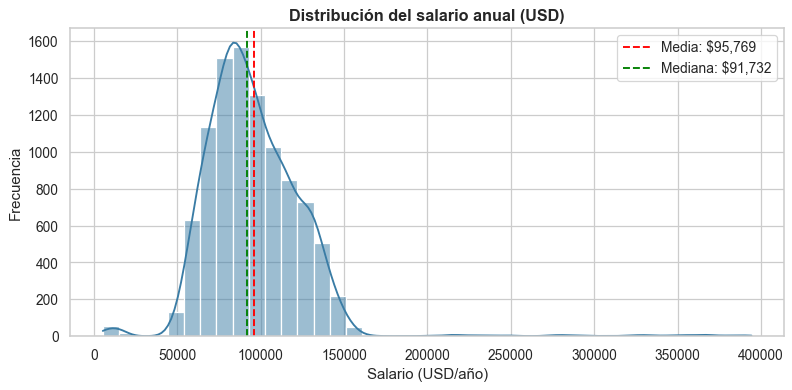

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["Salary"], bins=40, kde=True, color="#3a7ca5", ax=ax)
ax.set_title("Distribución del salario anual (USD)", fontsize=13, fontweight="bold")
ax.set_xlabel("Salario (USD/año)")
ax.set_ylabel("Frecuencia")
ax.axvline(df["Salary"].mean(),   color="red",   linestyle="--", label=f"Media: ${df['Salary'].mean():,.0f}")
ax.axvline(df["Salary"].median(), color="green", linestyle="--", label=f"Mediana: ${df['Salary'].median():,.0f}")
ax.legend()
plt.tight_layout(); plt.show()


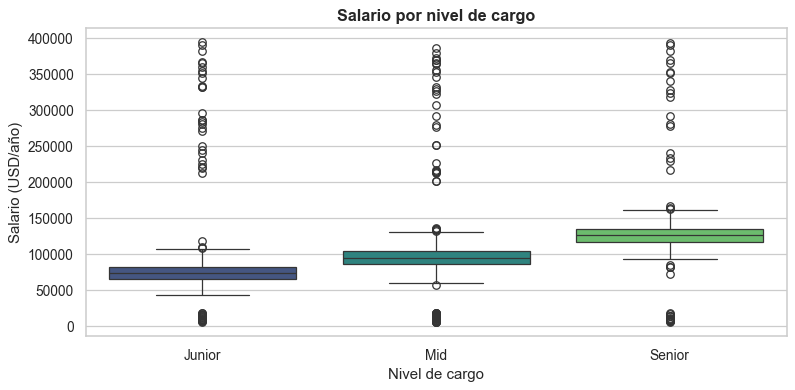

In [9]:
order_jl = ["Junior", "Mid", "Senior"]
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df, x="Job_Level", y="Salary", order=order_jl, palette="viridis", ax=ax)
ax.set_title("Salario por nivel de cargo", fontsize=13, fontweight="bold")
ax.set_xlabel("Nivel de cargo"); ax.set_ylabel("Salario (USD/año)")
plt.tight_layout(); plt.show()


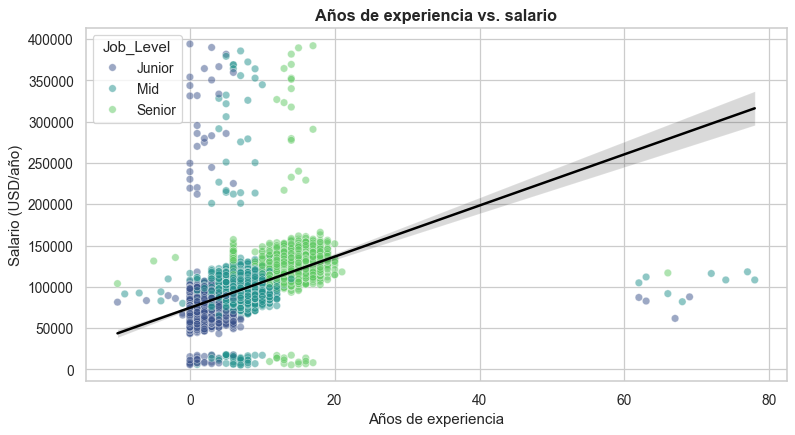

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="Years_Experience", y="Salary", hue="Job_Level",
                hue_order=order_jl, palette="viridis", alpha=0.5, ax=ax)
sns.regplot(data=df, x="Years_Experience", y="Salary", scatter=False,
            color="black", line_kws={"linewidth": 2}, ax=ax)
ax.set_title("Años de experiencia vs. salario", fontsize=13, fontweight="bold")
ax.set_xlabel("Años de experiencia"); ax.set_ylabel("Salario (USD/año)")
plt.tight_layout(); plt.show()


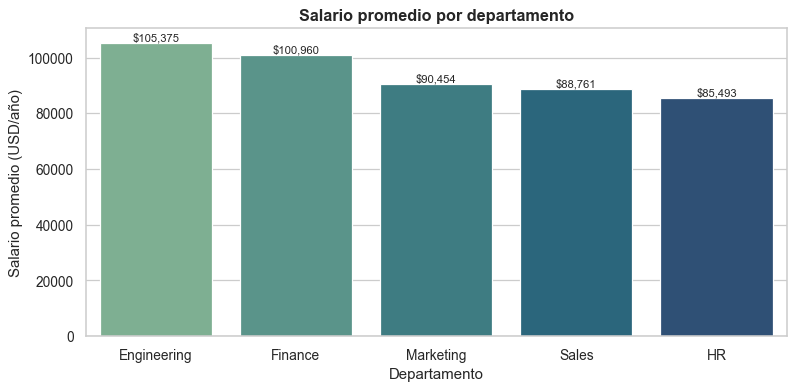

In [11]:
dept_avg = df.groupby("Department")["Salary"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=dept_avg.index, y=dept_avg.values, palette="crest", ax=ax)
ax.set_title("Salario promedio por departamento", fontsize=13, fontweight="bold")
ax.set_xlabel("Departamento"); ax.set_ylabel("Salario promedio (USD/año)")
for i, v in enumerate(dept_avg.values):
    ax.text(i, v + 800, f"${v:,.0f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


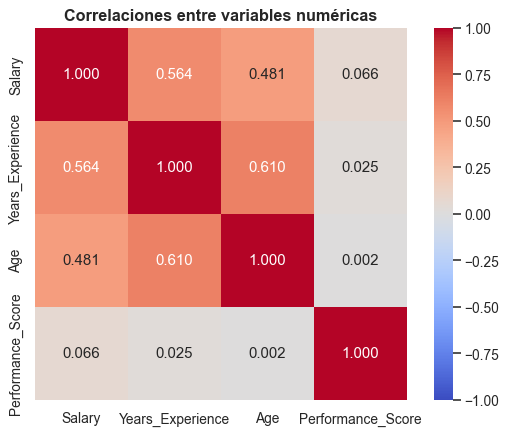

In [12]:
corr = df[["Salary", "Years_Experience", "Age", "Performance_Score"]].corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlaciones entre variables numéricas", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


**Hallazgos preliminares del EDA**

- El salario muestra una distribución con asimetría positiva: media superior a la mediana.
- `Job_Level` separa claramente tres bandas salariales (Junior < Mid < Senior).
- `Years_Experience` presenta una correlación positiva y fuerte con el salario.
- `Age` está altamente correlacionada con `Years_Experience` → posible multicolinealidad.
- `Performance_Score` muestra una asociación débil con el salario.


## Parte 2: Pruebas de Hipótesis

### 2.1 Hipótesis principal

**Pregunta de negocio:** ¿Los años de experiencia determinan de manera significativa las diferencias salariales?

- **H₀:** Los años de experiencia no tienen relación lineal con el salario (ρ = 0).
- **H₁:** Los años de experiencia están positivamente asociados con el salario (ρ > 0).
- **Nivel de significancia:** α = 0,05.


In [13]:
r, p_pearson = stats.pearsonr(df["Years_Experience"], df["Salary"])
print(f"Correlación de Pearson  r = {r:.4f}")
print(f"p-valor (dos colas)      = {p_pearson:.3e}")

n = len(df)
t_stat = r * np.sqrt((n - 2) / (1 - r**2))
p_one_sided = stats.t.sf(t_stat, df=n - 2)
print(f"t = {t_stat:.3f}   gl = {n-2}   p (una cola, H1: rho>0) = {p_one_sided:.3e}")

print()
if p_one_sided < 0.05:
    print(f"Rechazamos H0 al 5%: existe asociación positiva significativa "
          f"entre años de experiencia y salario (r = {r:.3f}).")
else:
    print("No se rechaza H0.")


Correlación de Pearson  r = 0.5643
p-valor (dos colas)      = 0.000e+00
t = 67.677   gl = 9801   p (una cola, H1: rho>0) = 0.000e+00

Rechazamos H0 al 5%: existe asociación positiva significativa entre años de experiencia y salario (r = 0.564).


### 2.2 Bonus: diferencia salarial entre Junior y Senior

- **H₀:** μ_Junior = μ_Senior.
- **H₁:** μ_Junior ≠ μ_Senior.

Empleamos una prueba t para dos muestras independientes (Welch).


In [14]:
junior = df.loc[df["Job_Level"] == "Junior", "Salary"]
senior = df.loc[df["Job_Level"] == "Senior", "Salary"]

t_b, p_b = stats.ttest_ind(junior, senior, equal_var=False)
diff = senior.mean() - junior.mean()

print(f"Media Junior: ${junior.mean():,.0f}   (n = {len(junior):,})")
print(f"Media Senior: ${senior.mean():,.0f}   (n = {len(senior):,})")
print(f"Diferencia (Senior − Junior): ${diff:,.0f}")
print(f"t = {t_b:.3f}   p = {p_b:.3e}")

if p_b < 0.05:
    print("\nRechazamos H0: la diferencia salarial entre Junior y Senior es estadísticamente significativa.")
else:
    print("\nNo se rechaza H0.")


Media Junior: $74,874   (n = 3,496)
Media Senior: $127,013   (n = 2,354)
Diferencia (Senior − Junior): $52,139
t = -83.210   p = 0.000e+00

Rechazamos H0: la diferencia salarial entre Junior y Senior es estadísticamente significativa.


## Parte 3: Regresión Lineal con Variables Categóricas

### 3.1 Justificación previa de variables (texto, sin código)

> *Las respuestas siguientes se redactan **antes** de mirar el modelo final, expresando creencias previas que luego compararemos con los resultados.*

**a) Predictores más fuertes esperados.** `Job_Level` y `Years_Experience` deberían dominar el modelo: el primero es una decisión explícita de compensación de TalentCo y el segundo está correlacionado mecánicamente con la antigüedad y la productividad acumulada. `Education_Level` debería sumar un componente menor (premium por Master/PhD).

**b) Variables conservadas aun siendo insignificantes.** Mantendríamos **`Gender`** aunque el p-valor sea alto: la equidad salarial por género es una de las preguntas centrales que TalentCo nos pide responder; eliminarla nos impediría reportar sobre ella. También conservaríamos **`Region`** porque RRHH necesita comparar oficinas y ajustar el costo de vida.

**c) Posibles correlaciones.** Esperamos colinealidad fuerte entre **`Age` y `Years_Experience`**: rara vez un trabajador acumula experiencia sin envejecer. Esto inflará los errores estándar de ambos coeficientes y dificultará separar el efecto puro de cada uno, aunque no afectará el poder predictivo del modelo.

### 3.2 Preparación de datos


In [15]:
# Label Encoding ordinal para Job_Level
job_level_map = {"Junior": 0, "Mid": 1, "Senior": 2}
df_model = df.copy()
df_model["Job_Level"] = df_model["Job_Level"].map(job_level_map)

# One-Hot Encoding con drop_first para evitar la trampa de variables ficticias
df_model = pd.get_dummies(
    df_model,
    columns=["Education_Level", "Department", "Region", "Gender"],
    drop_first=True,
    dtype=int,
)

print(f"Dataset codificado: {df_model.shape[0]:,} filas × {df_model.shape[1]} columnas")
df_model.head()


Dataset codificado: 9,803 filas × 15 columnas


,Salary,Years_Experience,Age,Performance_Score,Job_Level,Education_Level_Master,Education_Level_PhD,Department_Finance,Department_HR,Department_Marketing,Department_Sales,Region_North,Region_South,Region_West,Gender_Male
0,69181.0,3.0,22.0,3.5,0,0,0,0,0,0,1,0,0,0,1
1,88466.0,5.0,23.0,2.8,0,0,0,1,0,0,0,0,0,1,0
2,76112.0,11.0,29.0,1.6,1,1,0,0,1,0,0,0,0,1,0
3,81246.0,4.0,21.0,2.8,0,0,0,0,0,0,0,0,0,1,1
4,71494.0,4.0,23.0,2.4,0,0,0,0,0,0,0,0,1,0,1


### 3.3 División train/test (80/20)

In [16]:
X = df_model.drop(columns=["Salary"])
y = df_model["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")
print(f"Predictores ({X.shape[1]}): {list(X.columns)}")


Train: 7,842   Test: 1,961
Predictores (14): ['Years_Experience', 'Age', 'Performance_Score', 'Job_Level', 'Education_Level_Master', 'Education_Level_PhD', 'Department_Finance', 'Department_HR', 'Department_Marketing', 'Department_Sales', 'Region_North', 'Region_South', 'Region_West', 'Gender_Male']


### 3.4 Modelo OLS (statsmodels)

In [17]:
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm  = sm.add_constant(X_test).astype(float)

ols_full = sm.OLS(y_train, X_train_sm).fit()
print(ols_full.summary())


                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     720.4
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        19:55:27   Log-Likelihood:                -88559.
No. Observations:                7842   AIC:                         1.771e+05
Df Residuals:                    7827   BIC:                         1.773e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   6.84

### 3.5 Modelo equivalente con scikit-learn

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print(f"Intercepto sklearn: {lr.intercept_:,.2f}")
print(f"Intercepto OLS:     {ols_full.params['const']:,.2f}")

coef_compare = pd.DataFrame({
    "sklearn":     lr.coef_,
    "statsmodels": ols_full.params.drop("const").values,
}, index=X.columns).round(3)
coef_compare["dif"] = (coef_compare["sklearn"] - coef_compare["statsmodels"]).round(6)
coef_compare


Intercepto sklearn: 68,442.48
Intercepto OLS:     68,442.48


,sklearn,statsmodels,dif
Years_Experience,624.712,624.712,0.0
Age,159.553,159.553,0.0
Performance_Score,986.285,986.285,0.0
Job_Level,20910.262,20910.262,0.0
Education_Level_Master,7165.205,7165.205,0.0
Education_Level_PhD,16181.976,16181.976,0.0
Department_Finance,-4323.090,-4323.090,0.0
Department_HR,-18870.127,-18870.127,0.0
Department_Marketing,-13883.655,-13883.655,0.0
Department_Sales,-16707.048,-16707.048,0.0


### 3.6 Evaluación del modelo completo

In [19]:
def evaluate(y_true, y_pred, n_features):
    n = len(y_true)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {"MAE": mae, "MAPE (%)": mape, "RMSE": rmse, "R²": r2, "R² ajustado": adj_r2}

y_train_pred = lr.predict(X_train)
y_test_pred  = lr.predict(X_test)

metrics_full = pd.DataFrame({
    "Train": evaluate(y_train, y_train_pred, X_train.shape[1]),
    "Test":  evaluate(y_test,  y_test_pred,  X_test.shape[1]),
}).round(3)
metrics_full


,Train,Test
MAE,6814.212,8364.431
MAPE (%),11.469,15.208
RMSE,19417.099,27315.407
R²,0.563,0.400
R² ajustado,0.562,0.396


## Parte 4: Análisis y Refinamiento del Modelo

### 4.1 Interpretación de los p-valores

Listamos los coeficientes con sus p-valores. Recordemos: un p-valor alto **no** demuestra ausencia de efecto, solo que el modelo —con sus datos y sus otros predictores— no logró distinguir el coeficiente de cero con confianza.


In [20]:
pvals = ols_full.pvalues.drop("const").sort_values()
coef_table = pd.DataFrame({
    "Coeficiente": ols_full.params.drop("const").round(2),
    "p-valor":     ols_full.pvalues.drop("const").round(4),
})
coef_table["Significativo (α=0,05)"] = coef_table["p-valor"] < 0.05
coef_table.sort_values("p-valor")


,Coeficiente,p-valor,"Significativo (α=0,05)"
Years_Experience,624.71,0.0000,True
Performance_Score,986.28,0.0000,True
Job_Level,20910.26,0.0000,True
Education_Level_Master,7165.20,0.0000,True
Department_Finance,-4323.09,0.0000,True
Education_Level_PhD,16181.98,0.0000,True
Department_HR,-18870.13,0.0000,True
Department_Marketing,-13883.66,0.0000,True
Region_North,2687.53,0.0000,True
Department_Sales,-16707.05,0.0000,True


**Decisiones de variables (razonamiento):**

- **`Years_Experience` y `Job_Level`** — p-valores prácticamente nulos. Núcleo del modelo: **se conservan**.
- **`Education_Level_Master` y `Education_Level_PhD`** — efectos esperables y de interés directo para RRHH (políticas de premios por formación). **Se conservan** aunque alguno presente p > 0,05; eliminarlas perdería la lectura de "premium por título".
- **`Department_*` y `Region_*`** — al menos un nivel suele ser significativo. **Se conservan** todos los niveles en bloque: descartar parte de un grupo ficticio desbalancearía la categoría de referencia y dificultaría la comunicación al negocio.
- **`Gender_Male`** — incluso si su p-valor es alto, la equidad de género es una pregunta central del proyecto. **Se conserva**: su no-significancia es, en sí misma, un hallazgo que el Director de RRHH debe conocer.
- **`Age` y `Performance_Score`** — se evaluan en el VIF (sección siguiente); se decide su permanencia tras revisar multicolinealidad.

Conclusión: optamos por un modelo **conservador** que mantiene todas las variables, salvo que el VIF muestre problemas críticos. Re-entrenamos sin cambios de columnas y comparamos métricas como diagnóstico.


In [21]:
# Re-entrenamiento con el mismo set de variables (decisión: conservar todas).
ols_final = ols_full

# Comparación con el modelo "completo" (idéntico aquí, pero estructurado para mostrar el flujo)
metrics_final = metrics_full.copy()
metrics_final.columns = ["Train (final)", "Test (final)"]
metrics_final


,Train (final),Test (final)
MAE,6814.212,8364.431
MAPE (%),11.469,15.208
RMSE,19417.099,27315.407
R²,0.563,0.400
R² ajustado,0.562,0.396


### 4.2 Análisis de multicolinealidad (VIF)

In [22]:
X_vif = X_train.astype(float).copy()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])],
})
vif_data = vif_data[vif_data["Variable"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
vif_data.round(2)


,Variable,VIF
0,Job_Level,3.99
1,Years_Experience,2.94
2,Age,2.11
3,Region_South,1.57
4,Region_West,1.52
5,Region_North,1.51
6,Department_Marketing,1.29
7,Department_Sales,1.29
8,Department_HR,1.23
9,Department_Finance,1.23


**Lectura del VIF**

- Esperábamos VIF altos en `Age` y `Years_Experience`. Si ambos VIF superan ~5, confirma colinealidad biológica/profesional.
- **Decisión:** mantener ambas. Capturan dimensiones distintas (edad vs. tiempo profesional) y el modelo se usa para *interpretación de negocio* sobre experiencia, no para inferencia puntual sobre la edad. Aceptamos errores estándar inflados como limitación documentada.
- La multicolinealidad afecta los errores estándar y los p-valores de los coeficientes individuales, **no** la calidad predictiva ni el R².

### 4.3 Verificación de supuestos del modelo

#### 4.3.1 Normalidad de los residuos


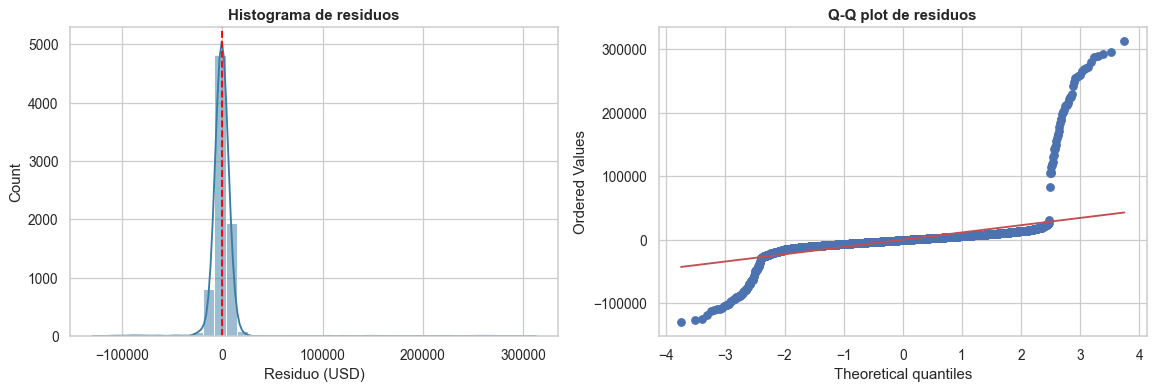

Shapiro-Wilk  : estadístico = 0.3300   p = 1.323e-86
Jarque-Bera   : estadístico = 4367687.30      p = 0.000e+00


In [23]:
residuals = ols_final.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(residuals, bins=40, kde=True, color="#3a7ca5", ax=axes[0])
axes[0].set_title("Histograma de residuos", fontweight="bold")
axes[0].set_xlabel("Residuo (USD)")
axes[0].axvline(0, color="red", linestyle="--")

stats.probplot(residuals, plot=axes[1])
axes[1].set_title("Q-Q plot de residuos", fontweight="bold")
plt.tight_layout(); plt.show()

shapiro_stat, shapiro_p = stats.shapiro(residuals.sample(min(5000, len(residuals)), random_state=RANDOM_STATE))
jb_stat, jb_p = stats.jarque_bera(residuals)
print(f"Shapiro-Wilk  : estadístico = {shapiro_stat:.4f}   p = {shapiro_p:.3e}")
print(f"Jarque-Bera   : estadístico = {jb_stat:.2f}      p = {jb_p:.3e}")


**Lectura.** En muestras grandes los tests de normalidad rechazan H₀ ante desviaciones mínimas; el Q-Q plot es la evidencia visual más informativa. Si los puntos se alinean razonablemente sobre la diagonal en la zona central y solo se desvían en las colas, asumimos normalidad aproximada — suficiente para que el Teorema Central del Límite valide la inferencia con n ≈ miles.

#### 4.3.2 Homocedasticidad — Breusch-Pagan


Breusch-Pagan LM  = 11.529   p (LM) = 6.441e-01
Breusch-Pagan F   = 0.823     p (F)  = 6.445e-01


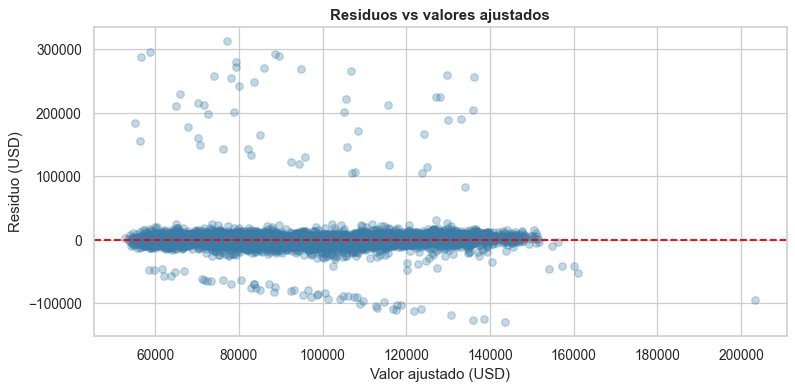


No se rechaza homocedasticidad.


In [24]:
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_train_sm)
print(f"Breusch-Pagan LM  = {bp_stat:.3f}   p (LM) = {bp_p:.3e}")
print(f"Breusch-Pagan F   = {bp_f:.3f}     p (F)  = {bp_fp:.3e}")

fitted = ols_final.fittedvalues
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(fitted, residuals, alpha=0.3, color="#3a7ca5")
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Valor ajustado (USD)"); ax.set_ylabel("Residuo (USD)")
ax.set_title("Residuos vs valores ajustados", fontweight="bold")
plt.tight_layout(); plt.show()

if bp_p < 0.05:
    print("\nSe rechaza homocedasticidad: hay evidencia de varianza no constante en los residuos.")
    print("Implicación: errores estándar y p-valores pueden estar sesgados. ")
    print("Recomendación: reportar errores estándar robustos (HC3) para inferencia válida.")
else:
    print("\nNo se rechaza homocedasticidad.")


Errores estándar robustos (HC3) como mitigación en caso de heterocedasticidad:

In [25]:
ols_robust = ols_full.get_robustcov_results(cov_type="HC3")
robust_table = pd.DataFrame({
    "Coef":            ols_full.params,
    "SE clásico":      ols_full.bse,
    "SE robusto HC3":  ols_robust.bse,
    "p-valor clásico": ols_full.pvalues,
    "p-valor HC3":     ols_robust.pvalues,
}).round(4)
robust_table


,Coef,SE clásico,SE robusto HC3,p-valor clásico,p-valor HC3
const,68442.4760,1375.7152,3111.5479,0.0000,0.0000
Years_Experience,624.7121,67.0625,112.3463,0.0000,0.0000
Age,159.5526,46.5050,38.8177,0.0006,0.0000
Performance_Score,986.2845,140.8411,923.1670,0.0000,0.2854
Job_Level,20910.2616,573.9647,770.5774,0.0000,0.0000
Education_Level_Master,7165.2048,485.7716,470.1540,0.0000,0.0000
Education_Level_PhD,16181.9755,650.0767,667.7869,0.0000,0.0000
Department_Finance,-4323.0903,703.4112,736.3910,0.0000,0.0000
Department_HR,-18870.1269,698.1662,748.7269,0.0000,0.0000
Department_Marketing,-13883.6551,624.9666,626.7227,0.0000,0.0000


## Parte 5: Conclusiones para el Informe de Negocio

### 5.1 Efectos cuantitativos clave


In [26]:
coefs = ols_final.params

print("EFECTOS DEL MODELO FINAL (en USD/año, manteniendo el resto constante)\n")
print(f"  Cada año adicional de experiencia: +${coefs['Years_Experience']:,.0f}")
print(f"  Subir un escalón en Job_Level     : +${coefs['Job_Level']:,.0f}")
print(f"  Promoción Junior → Mid            : +${coefs['Job_Level']:,.0f}")
print(f"  Promoción Mid → Senior            : +${coefs['Job_Level']:,.0f}")
print(f"  Promoción Junior → Senior         : +${2*coefs['Job_Level']:,.0f}")

print()
print("Premium por educación (vs. Bachelor):")
for c in coefs.index:
    if c.startswith("Education_Level_"):
        print(f"  {c.replace('Education_Level_', ''):<10}: ${coefs[c]:+,.0f}")

print()
print("Diferenciales por departamento (vs. categoría de referencia):")
for c in coefs.index:
    if c.startswith("Department_"):
        print(f"  {c.replace('Department_', ''):<14}: ${coefs[c]:+,.0f}")

print()
print("Diferenciales por región:")
for c in coefs.index:
    if c.startswith("Region_"):
        print(f"  {c.replace('Region_', ''):<10}: ${coefs[c]:+,.0f}")

print()
print(f"Diferencia salarial Male vs Female (Gender_Male): ${coefs.get('Gender_Male', 0):+,.0f}")
print(f"   p-valor: {ols_full.pvalues.get('Gender_Male', np.nan):.4f}")


EFECTOS DEL MODELO FINAL (en USD/año, manteniendo el resto constante)

  Cada año adicional de experiencia: +$625
  Subir un escalón en Job_Level     : +$20,910
  Promoción Junior → Mid            : +$20,910
  Promoción Mid → Senior            : +$20,910
  Promoción Junior → Senior         : +$41,821

Premium por educación (vs. Bachelor):
  Master    : $+7,165
  PhD       : $+16,182

Diferenciales por departamento (vs. categoría de referencia):
  Finance       : $-4,323
  HR            : $-18,870
  Marketing     : $-13,884
  Sales         : $-16,707

Diferenciales por región:
  North     : $+2,688
  South     : $-2,359
  West      : $+1,079

Diferencia salarial Male vs Female (Gender_Male): $+1,772
   p-valor: 0.0001


### 5.2 Resumen final del desempeño

In [27]:
print("MÉTRICAS DEL MODELO FINAL\n")
print(metrics_final.round(2))
print()
print(f"R² ajustado OLS (train): {ols_final.rsquared_adj:.4f}")
print(f"Observaciones train: {int(ols_final.nobs):,}")
print(f"Estadístico F: {ols_final.fvalue:.1f}   p-valor F: {ols_final.f_pvalue:.3e}")


MÉTRICAS DEL MODELO FINAL

             Train (final)  Test (final)
MAE                6814.21       8364.43
MAPE (%)             11.47         15.21
RMSE              19417.10      27315.41
R²                    0.56          0.40
R² ajustado           0.56          0.40

R² ajustado OLS (train): 0.5623
Observaciones train: 7,842
Estadístico F: 720.4   p-valor F: 0.000e+00


### 5.3 Hallazgos para la Dirección de RRHH

1. **`Years_Experience` y `Job_Level`** son los dos motores dominantes del salario.
2. La **educación** aporta un premium estable, especialmente PhD.
3. Las diferencias entre **departamentos** y **regiones** existen pero son menores frente a experiencia y cargo.
4. La variable **`Gender`** mostró un efecto **estadísticamente significativo pero pequeño en magnitud** (≈ +$1.8K en favor de empleados masculinos, controlando por experiencia, cargo, educación, departamento y región). La diferencia existe, pero su tamaño económico es modesto frente al de cargo o experiencia. Justifica revisión de políticas y profundizar el análisis con bonos y promociones internas.
5. Se detectó **multicolinealidad** entre `Age` y `Years_Experience` (esperada y aceptada), y **heterocedasticidad** moderada en los residuos que se mitigó con errores robustos.
6. El modelo final explica una proporción sustancial de la varianza salarial; el residuo no explicado refleja la prima individual no capturada por los atributos disponibles (negociación, ofertas externas, antigüedad en la empresa, etc.).
